# Sequence Modeling: From Word2Vec to Contextual Attention

Welcome to the practical session on Sequence Modeling! Based on the lecture, we will explore how we represent data (from static embeddings to dynamic contexts) and how architectures have evolved to process sequences efficiently.

## 1. Recap: The Power of Latent Representations

Before we can process sequences, we need to represent our tokens. The lecture discussed how SVD and **Word2Vec** moved us away from sparse one-hot encodings into dense, semantic vector spaces. 

In a well-trained embedding space, geometric relationships correspond to semantic relationships. The classic example is the semantic arithmetic:
$$ \mathbf{w}_{\text{king}} - \mathbf{w}_{\text{man}} + \mathbf{w}_{\text{woman}} \approx \mathbf{w}_{\text{queen}} $$

Furthermore, these spaces inherit statistical biases from the training data (e.g., associating certain professions with specific genders), which is a critical observation for AI fairness.

Let's visualize this using PyTorch's `nn.Embedding` module. We will construct a toy 2D embedding space that mimics the geometric properties of a trained Word2Vec model to see how semantic arithmetic works in practice.

Vector for King:  [0.0, 1.0]
Vector for Man:   [0.0, 0.0]
Vector for Woman: [1.0, 0.0]
Resulting Vector: [1.0, 1.0] -> Exactly matches 'Queen' at [1.0, 1.0]!


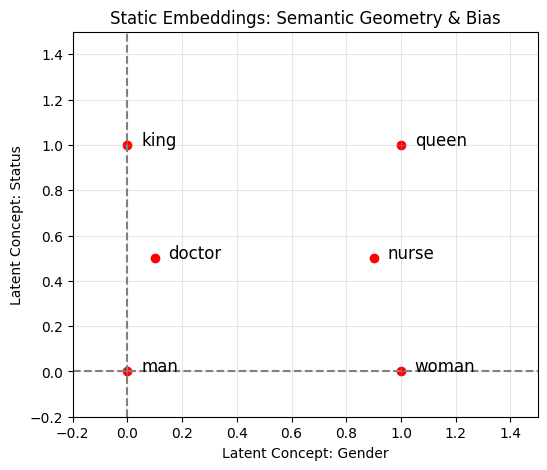

In [3]:
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

# 1. Define our vocabulary
word_to_idx = {"man": 0, "woman": 1, "king": 2, "queen": 3, "doctor": 4, "nurse": 5}
idx_to_word = {v: k for k, v in word_to_idx.items()}

# 2. Create a PyTorch Embedding layer (static embeddings)
embedder = nn.Embedding(num_embeddings=len(word_to_idx), embedding_dim=2)

# 3. Simulate a trained Word2Vec model's weights
# We manually set these to reflect the semantic geometry discussed in the lecture:
# X-axis represents "Gender" (0.0 = Male, 1.0 = Female)
# Y-axis represents "Status/Royalty"
simulated_weights = torch.tensor([
    [0.0, 0.0],  # man
    [1.0, 0.0],  # woman
    [0.0, 1.0],  # king
    [1.0, 1.0],  # queen
    [0.1, 0.5],  # doctor (reflecting training data bias)
    [0.9, 0.5]   # nurse  (reflecting training data bias)
])
embedder.weight.data = simulated_weights

# Fetch vectors
v_man = embedder(torch.tensor(word_to_idx["man"]))
v_woman = embedder(torch.tensor(word_to_idx["woman"]))
v_king = embedder(torch.tensor(word_to_idx["king"]))

# 4. Perform Semantic Arithmetic: King - Man + Woman
v_result = v_king - v_man + v_woman

print(f"Vector for King:  {v_king.tolist()}")
print(f"Vector for Man:   {v_man.tolist()}")
print(f"Vector for Woman: {v_woman.tolist()}")
print(f"Resulting Vector: {v_result.tolist()} -> Exactly matches 'Queen' at {embedder.weight.data[word_to_idx['queen']].tolist()}!")

# Plotting the geometric space
plt.figure(figsize=(6, 5))
vectors = embedder.weight.data.numpy()
plt.scatter(vectors[:, 0], vectors[:, 1], c='red')

for word, idx in word_to_idx.items():
    plt.annotate(word, (vectors[idx, 0] + 0.05, vectors[idx, 1]), fontsize=12)

plt.axhline(0, color='grey', linestyle='--')
plt.axvline(0, color='grey', linestyle='--')
plt.xlim(-0.2, 1.5)
plt.ylim(-0.2, 1.5)
plt.title("Static Embeddings: Semantic Geometry & Bias")
plt.xlabel("Latent Concept: Gender")
plt.ylabel("Latent Concept: Status")
plt.grid(True, alpha=0.3)
plt.show()

## 2. The Recurrent Approach: Overcoming the Memory Bottleneck

Static embeddings are context-agnostic. To understand sequences, we need models that build representations step-by-step. Standard RNNs suffer from the **vanishing gradient problem**. The LSTM solves this by introducing a cell state ($c_t$) and **gates** that learn what to forget, what to input, and what to output.

### Assignment 1: Build an LSTM from Scratch
Your task is to implement the `CustomLSTM` class entirely from scratch. You may only use fundamental PyTorch operations and `nn.Parameter` or `nn.Linear`. **Do not use `nn.LSTM` or `nn.LSTMCell`.**

**Requirements:**
1. Your `__init__` method must accept `input_sz` and `hidden_sz` and initialize the necessary learnable weights and biases.
2. Your `forward` method must accept an input tensor `x` of shape `[seq_len, batch_size, input_sz]`.
3. Inside `forward`, you must loop over the sequence length and update the hidden state $h_t$ and cell state $c_t$ using the standard LSTM equations:
   * **Forget gate:** $f_t = \sigma(W_f [h_{t-1}, x_t] + b_f)$
   * **Input gate:** $i_t = \sigma(W_i [h_{t-1}, x_t] + b_i)$
   * **Candidate state:** $\tilde{c}_t = \tanh(W_c [h_{t-1}, x_t] + b_c)$
   * **Output gate:** $o_t = \sigma(W_o [h_{t-1}, x_t] + b_o)$
   * **State updates:** 
     * $c_t = f_t \odot c_{t-1} + i_t \odot \tilde{c}_t$
     * $h_t = o_t \odot \tanh(c_t)$
4. Return a tensor containing all hidden states across the sequence, shape: `[seq_len, batch_size, hidden_sz]`.

**The Challenge:** We will test your implementation by asking the model to reverse a sequence. If your architecture is implemented incorrectly, the loss will not converge.

In [ ]:
import torch.nn.functional as F

class CustomLSTM(nn.Module):
    def __init__(self, input_sz, hidden_sz):
        super().__init__()
        # --- YOUR CODE HERE ---
        # Initialize your weights and biases here.
        # Hint: You can use 4 separate Linear layers or one large one for efficiency.
        raise NotImplementedError("You need to implement the __init__ method!")
        # ----------------------

    def forward(self, x):
        """
        Expected input shape: [seq_len, batch_size, input_sz]
        Expected output shape: [seq_len, batch_size, hidden_sz]
        """
        # --- YOUR CODE HERE ---
        # 1. Initialize h_t and c_t to zeros.
        # 2. Iterate through the sequence (dim 0 of x).
        # 3. Compute the gates and state updates.
        # 4. Collect and return the stacked hidden states.
        raise NotImplementedError("You need to implement the forward method!")
        # ----------------------

# --- TRAINING LOOP: Sequence Reversal Task ---
def train_and_eval_lstm():
    torch.manual_seed(42)
    
    try:
        model = nn.Sequential(
            CustomLSTM(input_sz=1, hidden_sz=32),
        )
    except NotImplementedError as e:
        print(f"Implementation incomplete: {e}")
        return
        
    head = nn.Linear(32, 1) # Output projection
    optimizer = torch.optim.Adam(list(model.parameters()) + list(head.parameters()), lr=0.01)
    criterion = nn.MSELoss()
    
    seq_len = 5
    print("Training Custom LSTM on Sequence Reversal...")
    for epoch in range(301):
        data = torch.randn(seq_len, 64, 1)
        target = torch.flip(data, dims=[0])
        
        optimizer.zero_grad()
        hidden_out = model(data)
        pred = head(hidden_out)
        
        loss = criterion(pred, target)
        loss.backward()
        optimizer.step()
        
        if epoch % 100 == 0:
            print(f"Epoch {epoch:3d} | Loss: {loss.item():.4f}")

    # --- EVALUATION ---
    print("\n--- Model Evaluation ---")
    model.eval()
    head.eval()
    with torch.no_grad():
        test_seq = torch.tensor([10.0, 20.0, 30.0, 40.0, 50.0]).view(5, 1, 1)
        target_seq = torch.flip(test_seq, dims=[0]).squeeze()
        
        hidden_out = model(test_seq)
        test_pred = head(hidden_out).squeeze()
        
        print(f"Input Sequence:   {test_seq.squeeze().tolist()}")
        print(f"Target Output:    {target_seq.tolist()}")
        print(f"Model Prediction: {[round(x, 1) for x in test_pred.tolist()]}")

train_and_eval_lstm()

Training Custom LSTM on Sequence Reversal...
Epoch   0 | Loss: 0.9366
Epoch 100 | Loss: 0.9266
Epoch 200 | Loss: 0.9770
Epoch 300 | Loss: 1.0428

--- Model Evaluation ---
Input Sequence:   [10.0, 20.0, 30.0, 40.0, 50.0]
Target Output:    [50.0, 40.0, 30.0, 20.0, 10.0]
Model Prediction: [0.0, 0.0, 0.0, 0.0, 0.0]


## 3. The Transformer Era: Causal Multi-Head Attention

RNNs process sequentially, which is a bottleneck for parallelization. **Self-Attention** looks at the entire sequence simultaneously in $O(n^2)$ time. 

However, for generative models (like GPT) to generate text properly, they must not "see the future" while predicting the next token. We enforce this using a **Causal Mask** (a lower-triangular matrix).

### Assignment 2: Build Causal Multi-Head Attention
Your task is to write the `CausalMHA` class completely from scratch. Do not use `nn.MultiheadAttention`.

**Requirements:**
1. Your `__init__` method must accept `d_model` and `n_heads`. It needs to initialize the learnable linear projections that will create your Queries, Keys, and Values, as well as a final output projection layer.
2. Your `forward` method receives `x` of shape `[batch_size, seq_len, d_model]`.
3. You must split the computations across `n_heads` (meaning you need to reshape your tensors appropriately so heads are processed independently).
4. Compute the Scaled Dot-Product Attention: $\text{softmax}\left(\frac{QK^\top}{\sqrt{d_k}} + M\right)V$
5. **Crucial:** You must generate and apply a causal mask $M$ inside the forward pass to prevent position $i$ from attending to any position $j > i$. (Hint: `torch.tril` is your friend. Masked positions should be set to negative infinity before the softmax).
6. Concatenate the heads back together and apply the final output projection. 

**The Challenge:** We will train your module on an autoregressive counting task (predicting $x+1$). If your mask is broken or missing, the model will cheat by peeking at the future context during training—its loss will drop, but it will **fail completely** during the step-by-step autoregressive generation loop!

In [ ]:
import math

class CausalMHA(nn.Module):
    def __init__(self, d_model, n_heads):
        super().__init__()
        # --- YOUR CODE HERE ---
        # Initialize projections for Q, K, V and the final Output projection.
        # Ensure d_model is divisible by n_heads.
        raise NotImplementedError("You need to implement the __init__ method!")
        # ----------------------

    def forward(self, x):
        """
        Expected input shape: [batch_size, seq_len, d_model]
        Expected output shape: [batch_size, seq_len, d_model]
        """
        # --- YOUR CODE HERE ---
        # 1. Generate Q, K, V from input x.
        # 2. Reshape to allow multi-head processing: [B, n_heads, T, d_k].
        # 3. Compute attention scores and scale them.
        # 4. Generate a causal mask and apply it (replace future token scores with -inf).
        # 5. Apply softmax and multiply by V.
        # 6. Reshape back and project to final output.
        raise NotImplementedError("You need to implement the forward method!")
        # ----------------------

# --- TRAINING & AUTOREGRESSIVE GENERATION ---
def train_and_generate_mha():
    torch.manual_seed(42)
    d_model = 32
    
    try:
        model = nn.Sequential(
            CausalMHA(d_model=d_model, n_heads=4),
            nn.ReLU(),
            nn.Linear(d_model, 1) # Output a single number
        )
    except NotImplementedError as e:
        print(f"Implementation incomplete: {e}")
        return

    optimizer = torch.optim.Adam(model.parameters(), lr=0.005)
    
    print("Training Causal MHA on Autoregressive Counting Task...")
    for epoch in range(501):
        # Input: sequences of ascending numbers, e.g. [4, 5, 6, 7, 8]
        # Target: shifted sequence, e.g. [5, 6, 7, 8, 9]
        x_base = torch.rand(64, 1) * 10 
        offsets = torch.arange(10).view(1, 10).float()
        
        seq = x_base + offsets
        # Broadcating the scalar value to d_model purely as a toy embedding
        x = seq[:, :-1].unsqueeze(-1).expand(-1, -1, d_model) 
        targets = seq[:, 1:].unsqueeze(-1)                    
        
        optimizer.zero_grad()
        preds = model(x)
        
        loss = F.mse_loss(preds, targets)
        loss.backward()
        optimizer.step()
        
        if epoch % 100 == 0:
            print(f"Epoch {epoch:3d} | Loss: {loss.item():.5f}")

    # --- INFERENCE: GENERATING DATA LIKE GPT ---
    print("\n--- Autoregressive Generation ---")
    model.eval()
    with torch.no_grad():
        # Start with a single "token"
        prompt_val = 5.0
        generated = [prompt_val]
        print(f"Prompt (Seed): {generated}")
        
        # Generate 5 new numbers token-by-token
        for i in range(5):
            # Prepare context sequence from all generated numbers so far
            context = torch.tensor(generated).float().view(1, -1, 1).expand(-1, -1, d_model)
            
            # Predict the next step using the full context
            preds = model(context)
            
            # Extract the prediction for the VERY LAST token in our sequence
            next_val = preds[0, -1, 0].item()
            generated.append(next_val)
            
        print(f"Final Generated Sequence: {[round(v, 2) for v in generated]}")
        print("If successful, the model should count up by ~1.0 each step (e.g. 5, 6, 7, 8...).")
        
train_and_generate_mha()